In [2]:
# =========================================================
# Block 1: Imports and Global Setup
# CS3807 - Deep Learning Lab | Experiment 6
# RNN / LSTM / GRU - Sequence Learning & Video Understanding
# =========================================================

import os
import io
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------------------------------------
# Font Setup: Times New Roman, size 16
# times.ttf is expected to be uploaded to the Colab runtime
# at /content/times.ttf (adjust path if uploaded elsewhere)
# ---------------------------------------------------------
FONT_PATH = "/content/times.ttf"

if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    font_name = fm.FontProperties(fname=FONT_PATH).get_name()
else:
    # Fallback if font file isn't found yet in runtime
    font_name = "Times New Roman"
    print(f"[Warning] {FONT_PATH} not found yet. "
          f"Upload times.ttf to /content/ before plotting.")

rcParams["font.family"] = font_name
rcParams["font.size"] = 16
rcParams["axes.titlesize"] = 16
rcParams["axes.labelsize"] = 16
rcParams["xtick.labelsize"] = 16
rcParams["ytick.labelsize"] = 16
rcParams["legend.fontsize"] = 16
rcParams["figure.titlesize"] = 16

# ---------------------------------------------------------
# Output directory for all saved plots
# ---------------------------------------------------------
PLOT_DIR = "/content/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ---------------------------------------------------------
# save_plot(): saves current/given figure as .eps if the
# rendered file would be < 100KB, else falls back to .pdf.
# Determined by actually rendering to a buffer and checking size.
# ---------------------------------------------------------
def save_plot(fig, filename, plot_dir=PLOT_DIR, size_threshold_kb=100, dpi=300):
    """
    Save a matplotlib figure as EPS if under size_threshold_kb (default 100KB),
    otherwise save as PDF. Font is enforced as Times New Roman, size 16.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
    filename : str  (without extension)
    plot_dir : str  (output directory)
    size_threshold_kb : float
    dpi : int

    Returns
    -------
    str : path of the saved file
    """
    os.makedirs(plot_dir, exist_ok=True)

    # Render to an in-memory EPS buffer first to check size
    eps_buffer = io.BytesIO()
    fig.savefig(eps_buffer, format="eps", dpi=dpi, bbox_inches="tight")
    eps_size_kb = eps_buffer.tell() / 1024.0

    if eps_size_kb < size_threshold_kb:
        out_path = os.path.join(plot_dir, f"{filename}.eps")
        with open(out_path, "wb") as f:
            f.write(eps_buffer.getvalue())
        print(f"Saved (EPS, {eps_size_kb:.1f} KB): {out_path}")
    else:
        out_path = os.path.join(plot_dir, f"{filename}.pdf")
        fig.savefig(out_path, format="pdf", dpi=dpi, bbox_inches="tight")
        pdf_size_kb = os.path.getsize(out_path) / 1024.0
        print(f"EPS too large ({eps_size_kb:.1f} KB) -> "
              f"Saved (PDF, {pdf_size_kb:.1f} KB): {out_path}")

    eps_buffer.close()
    return out_path

# ---------------------------------------------------------
# Sanity check
# ---------------------------------------------------------
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Font in use:", rcParams["font.family"], "| size:", rcParams["font.size"])

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Font in use: ['Times New Roman'] | size: 16.0


In [4]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
zip_path = "/content/uci_har.zip"
extract_path = "/content/UCI HAR Dataset"

# 1. Download
print("Downloading dataset...")
urllib.request.urlretrieve(url, zip_path)

# 2. Extract outer zip
print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# 3. Extract inner dataset zip if nested
inner_zip = "/content/UCI HAR Dataset.zip"
if os.path.exists(inner_zip):
    with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
        zip_ref.extractall("/content/")

print("Extraction complete!")

Extracting...
Extraction complete!


In [5]:
# =========================================================
# Block 2: Dataset Loading, Windowing, Subsetting & Scaling
# UCI HAR Dataset -> (N, 128, 9) tensors
# =========================================================

DATA_ROOT = "/content/UCI HAR Dataset"

# ---------------------------------------------------------
# 9 inertial signal channels, in a fixed, documented order.
# This order is preserved consistently for RNN/LSTM/GRU.
# ---------------------------------------------------------
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_signals(split):
    """
    Load and stack the 9 inertial signal files for a given split
    ('train' or 'test') into a tensor of shape (N, 128, 9).
    """
    signals = []
    for name in SIGNAL_NAMES:
        path = os.path.join(DATA_ROOT, split, "Inertial Signals",
                             f"{name}_{split}.txt")
        # Whitespace-separated, 128 columns per row
        arr = np.loadtxt(path)  # shape: (N, 128)
        signals.append(arr)
    # Stack along last axis -> (N, 128, 9)
    X = np.stack(signals, axis=-1)
    return X

def load_labels(split):
    """
    Load activity labels (1-6) and convert to 0-indexed (0-5).
    """
    path = os.path.join(DATA_ROOT, split, f"y_{split}.txt")
    y = np.loadtxt(path).astype(int) - 1  # 0-indexed
    return y

# ---------------------------------------------------------
# Load full raw train and test sets
# ---------------------------------------------------------
X_train_full = load_signals("train")   # (7352, 128, 9) approx
y_train_full = load_labels("train")

X_test_full = load_signals("test")     # (2947, 128, 9) approx
y_test_full = load_labels("test")

print("Raw full train shape:", X_train_full.shape, "| labels:", y_train_full.shape)
print("Raw full test shape :", X_test_full.shape, "| labels:", y_test_full.shape)
print("Unique labels (train):", np.unique(y_train_full))

ACTIVITY_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING",
]
NUM_CLASSES = len(ACTIVITY_NAMES)
SEQ_LEN = 128
NUM_FEATURES = 9

# ---------------------------------------------------------
# Laboratory subset: stratified sample of N = 2400 windows
# from the training set, preserving class balance.
# ---------------------------------------------------------
N_SUBSET = 2400

X_subset, _, y_subset, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=N_SUBSET,
    stratify=y_train_full,
    random_state=SEED,
)

print("\nStratified training subset shape:", X_subset.shape)
print("Class distribution in subset:")
for cls in range(NUM_CLASSES):
    count = np.sum(y_subset == cls)
    print(f"  {ACTIVITY_NAMES[cls]:20s}: {count}")

# ---------------------------------------------------------
# Train / Validation split (from the 2400 subset)
# Overall protocol target: 70% train, 15% val, 15% test
# -> val_size = 15/85 of the subset, test = official UCI test set
# ---------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_subset, y_subset,
    test_size=15 / 85,          # ~17.65% of subset -> ~15% of grand total
    stratify=y_subset,
    random_state=SEED,
)

# Test set: official UCI test partition (kept fully independent,
# never touched during model selection or tuning)
X_test, y_test = X_test_full, y_test_full

print("\nSplit shapes before scaling:")
print("  Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

# ---------------------------------------------------------
# Scaling: StandardScaler fitted ONLY on training data,
# reshaped to (N*128, 9), then applied to all partitions.
# ---------------------------------------------------------
scaler = StandardScaler()

N_tr = X_train.shape[0]
N_va = X_val.shape[0]
N_te = X_test.shape[0]

scaler.fit(X_train.reshape(-1, NUM_FEATURES))  # fit on train only

X_train_scaled = scaler.transform(X_train.reshape(-1, NUM_FEATURES)).reshape(N_tr, SEQ_LEN, NUM_FEATURES)
X_val_scaled   = scaler.transform(X_val.reshape(-1, NUM_FEATURES)).reshape(N_va, SEQ_LEN, NUM_FEATURES)
X_test_scaled  = scaler.transform(X_test.reshape(-1, NUM_FEATURES)).reshape(N_te, SEQ_LEN, NUM_FEATURES)

# ---------------------------------------------------------
# Expected Preprocessing Output (per assignment Section 5)
# ---------------------------------------------------------
print("\n--- Expected Preprocessing Output ---")
print("Input tensor shape:")
print(f"  Training   : {X_train_scaled.shape}")
print(f"  Validation : {X_val_scaled.shape}")
print(f"  Testing    : {X_test_scaled.shape}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Number of features per time step: {NUM_FEATURES}")
print(f"Sequence length: {SEQ_LEN}")

# ---------------------------------------------------------
# Class distribution verification across all three splits
# ---------------------------------------------------------
def print_class_distribution(y, split_name):
    print(f"\nClass distribution ({split_name}):")
    for cls in range(NUM_CLASSES):
        count = np.sum(y == cls)
        pct = 100 * count / len(y)
        print(f"  {ACTIVITY_NAMES[cls]:20s}: {count:5d} ({pct:5.2f}%)")

print_class_distribution(y_train, "Train")
print_class_distribution(y_val, "Validation")
print_class_distribution(y_test, "Test")

Raw full train shape: (7352, 128, 9) | labels: (7352,)
Raw full test shape : (2947, 128, 9) | labels: (2947,)
Unique labels (train): [0 1 2 3 4 5]

Stratified training subset shape: (2400, 128, 9)
Class distribution in subset:
  WALKING             : 400
  WALKING_UPSTAIRS    : 350
  WALKING_DOWNSTAIRS  : 322
  SITTING             : 420
  STANDING            : 449
  LAYING              : 459

Split shapes before scaling:
  Train: (1976, 128, 9) | Val: (424, 128, 9) | Test: (2947, 128, 9)

--- Expected Preprocessing Output ---
Input tensor shape:
  Training   : (1976, 128, 9)
  Validation : (424, 128, 9)
  Testing    : (2947, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (Train):
  WALKING             :   329 (16.65%)
  WALKING_UPSTAIRS    :   288 (14.57%)
  WALKING_DOWNSTAIRS  :   265 (13.41%)
  SITTING             :   346 (17.51%)
  STANDING            :   370 (18.72%)
  LAYING              :   378 (19.13%)

Class distributio

Saved (EPS, 82.6 KB): /content/plots/plot1_temporal_signals_by_activity.eps


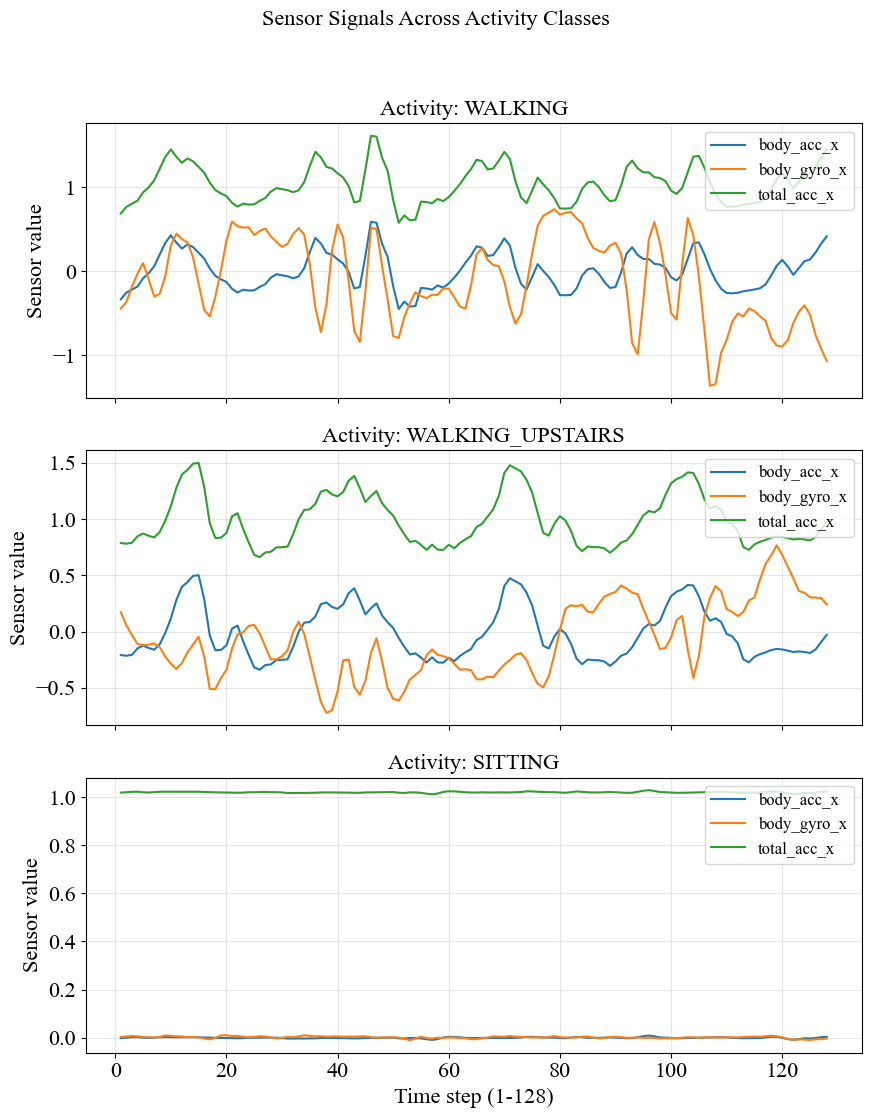

In [6]:
# =========================================================
# Block 3: Temporal Data Visualization (Section 6)
# Plot 1: Sensor signal vs. time, across activity classes
# =========================================================

# ---------------------------------------------------------
# Select representative sequences from 3 distinct activity
# classes: one dynamic (WALKING), one static (SITTING),
# and one transitional (WALKING_UPSTAIRS) for contrast.
# ---------------------------------------------------------
selected_activities = ["WALKING", "WALKING_UPSTAIRS", "SITTING"]
selected_class_ids = [ACTIVITY_NAMES.index(a) for a in selected_activities]

# Pick one representative window index per selected class (from training data)
rep_indices = {}
for cls_id, act_name in zip(selected_class_ids, selected_activities):
    idx = np.where(y_train == cls_id)[0][0]   # first matching window
    rep_indices[act_name] = idx

# ---------------------------------------------------------
# Channels to plot (at least 3 required):
# body_acc_x, body_gyro_x, total_acc_x
# Indices follow SIGNAL_NAMES order from Block 2:
# [body_acc_x, body_acc_y, body_acc_z,
#  body_gyro_x, body_gyro_y, body_gyro_z,
#  total_acc_x, total_acc_y, total_acc_z]
# ---------------------------------------------------------
channel_indices = {
    "body_acc_x": 0,
    "body_gyro_x": 3,
    "total_acc_x": 6,
}

time_steps = np.arange(1, SEQ_LEN + 1)  # 1 to 128

# ---------------------------------------------------------
# Plot 1: one subplot per activity, 3 channels overlaid
# ---------------------------------------------------------
fig, axes = plt.subplots(len(selected_activities), 1,
                          figsize=(9, 11), sharex=True)

for ax, act_name in zip(axes, selected_activities):
    idx = rep_indices[act_name]
    window = X_train[idx]  # unscaled, raw (128, 9) for interpretability

    for ch_name, ch_idx in channel_indices.items():
        ax.plot(time_steps, window[:, ch_idx], label=ch_name, linewidth=1.5)

    ax.set_title(f"Activity: {act_name}")
    ax.set_ylabel("Sensor value")
    ax.legend(loc="upper right", fontsize=12)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time step (1-128)")
fig.suptitle("Sensor Signals Across Activity Classes", y=1.02)
fig.tight_layout()

save_plot(fig, "plot1_temporal_signals_by_activity")
plt.show()


In [9]:

# ---------------------------------------------------------
# Programmatic verification using TensorFlow's SimpleRNNCell
# with weights fixed to match the manual exercise exactly.
# ---------------------------------------------------------
# Given values
x_vals = [0.5, 0.7, 0.2]
h0 = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

cell = layers.SimpleRNNCell(units=1, activation="tanh")
cell.build(input_shape=(None, 1))

# SimpleRNNCell weights: kernel (Wx), recurrent_kernel (Wh), bias (b)
cell.set_weights([
    np.array([[Wx]], dtype=np.float32),   # kernel
    np.array([[Wh]], dtype=np.float32),   # recurrent_kernel
    np.array([b], dtype=np.float32),      # bias
])

h_tf = tf.zeros((1, 1))
tf_hidden_states = []
for x_t in x_vals:
    x_input = tf.constant([[x_t]], dtype=tf.float32)
    h_tf, _ = cell(x_input, [h_tf])
    tf_hidden_states.append(float(h_tf.numpy()[0, 0]))

print("\nProgrammatic (TensorFlow) computation:")
print(f"  h1 = {tf_hidden_states[0]:.6f}")
print(f"  h2 = {tf_hidden_states[1]:.6f}")
print(f"  h3 = {tf_hidden_states[2]:.6f}")




Programmatic (TensorFlow) computation:
  h1 = 0.336376
  h2 = 0.616352
  h3 = 0.599958


In [10]:
# =========================================================
# Block 5: Vanilla RNN Model (Section 9)
# Input(128,9) -> SimpleRNN(32) -> Dropout(0.2) -> Dense(16, relu)
# -> Dense(6, softmax)
# =========================================================

def build_rnn_model(seq_len=SEQ_LEN, n_features=NUM_FEATURES, n_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.SimpleRNN(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="Vanilla_RNN")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

rnn_model = build_rnn_model()
rnn_model.summary()

rnn_num_params = rnn_model.count_params()
print(f"\nTotal trainable parameters (RNN): {rnn_num_params}")

# ---------------------------------------------------------
# Training
# ---------------------------------------------------------
EPOCHS = 30
BATCH_SIZE = 32

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

rnn_training_time = time.time() - start_time
print(f"\nRNN training time: {rnn_training_time:.2f} seconds")

Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters (RNN): 1974
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.2986 - loss: 1.6181 - val_accuracy: 0.4670 - val_loss: 1.4080
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5380 - loss: 1.2916 - val_accuracy: 0.6368 - val_loss: 1.1097
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6290 - loss: 1.0485 - val_accuracy: 0.6321 - val_loss: 0.9462
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6351 - loss: 0.9242 - val_accuracy: 0.6462 - val_loss: 0.8366
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6285 - loss: 0.9200 - val_accuracy: 0.6651 - val_loss: 0.8271
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6528 - loss: 0.8522 - val_accuracy: 0.6840 - val_loss: 0.8306
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6609 - loss: 0.8195 - val_accuracy: 0.6745 - val_loss: 0.7909
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6781 

In [12]:
# =========================================================
# Block 6: LSTM and GRU Models (Sections 10-12)
# Same classifier architecture as RNN, only the recurrent
# layer differs. All other conditions held constant.
# =========================================================

def build_lstm_model(seq_len=SEQ_LEN, n_features=NUM_FEATURES, n_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="LSTM")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_gru_model(seq_len=SEQ_LEN, n_features=NUM_FEATURES, n_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.GRU(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="GRU")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# ---------------------------------------------------------
# Build both models
# ---------------------------------------------------------
lstm_model = build_lstm_model()
lstm_model.summary()
lstm_num_params = lstm_model.count_params()
print(f"\nTotal trainable parameters (LSTM): {lstm_num_params}")

gru_model = build_gru_model()
gru_model.summary()
gru_num_params = gru_model.count_params()
print(f"\nTotal trainable parameters (GRU): {gru_num_params}")

# ---------------------------------------------------------
# Train LSTM
# ---------------------------------------------------------
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

lstm_training_time = time.time() - start_time
print(f"\nLSTM training time: {lstm_training_time:.2f} seconds")

# ---------------------------------------------------------
# Train GRU
# ---------------------------------------------------------
start_time = time.time()

gru_history = gru_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

gru_training_time = time.time() - start_time
print(f"\nGRU training time: {gru_training_time:.2f} seconds")

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters (GRU): 4758
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.3467 - loss: 1.6007 - val_accuracy: 0.4693 - val_loss: 1.3758
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5506 - loss: 1.2038 - val_accuracy: 0.6840 - val_loss: 0.9232
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7039 - loss: 0.7692 - val_accuracy: 0.7311 - val_loss: 0.6573
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7824 - loss: 0.5555 - val_accuracy: 0.8231 - val_loss: 0.4497
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8654 - loss: 0.4015 - val_accuracy: 0.9033 - val_loss: 0.3408
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8932 - loss: 0.3227 - val_accuracy: 0.9175 - val_loss: 0.2447
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8957 - loss: 0.3059 - val_accuracy: 0.9292 - val_loss: 0.2415
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9130 -

Saved (EPS, 32.3 KB): /content/plots/plot2_rnn_loss_curve.eps


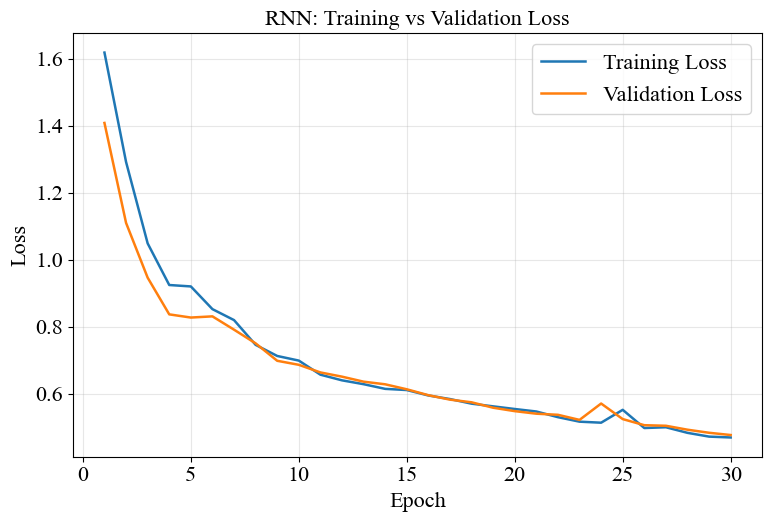

Saved (EPS, 36.1 KB): /content/plots/plot3_rnn_accuracy_curve.eps


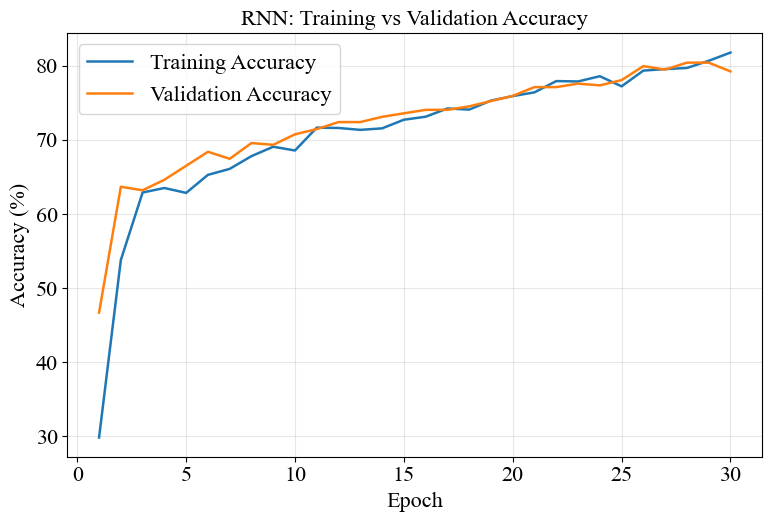

Saved (EPS, 33.5 KB): /content/plots/plot2_lstm_loss_curve.eps


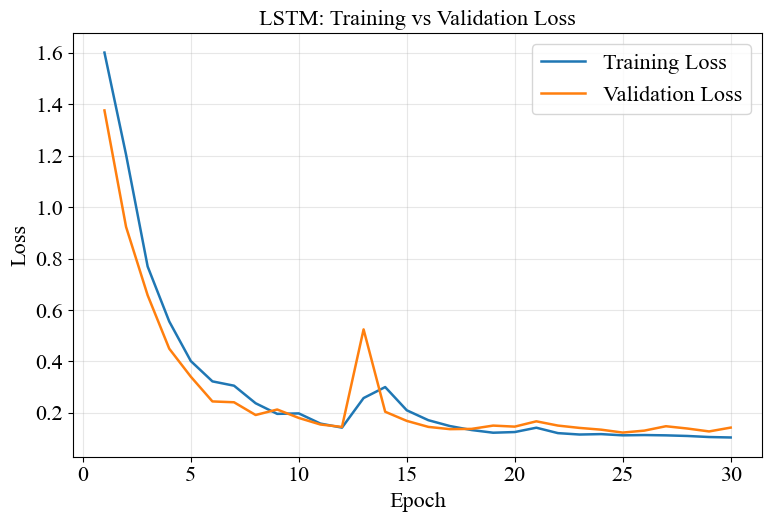

Saved (EPS, 37.6 KB): /content/plots/plot3_lstm_accuracy_curve.eps


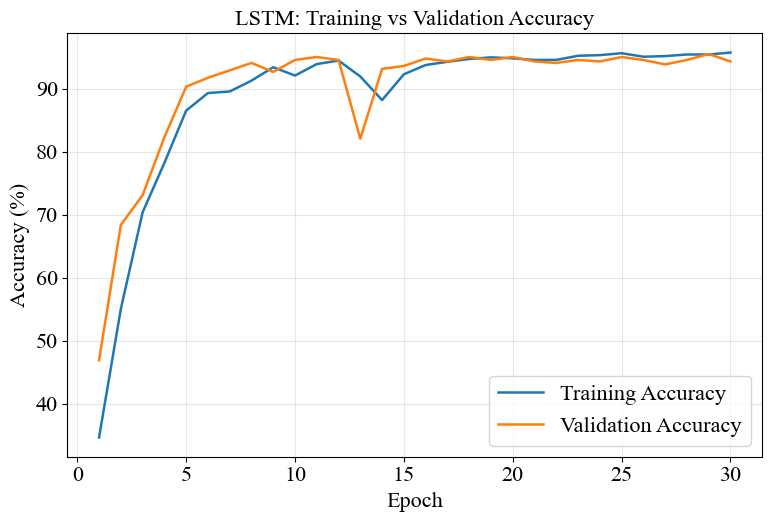

Saved (EPS, 34.4 KB): /content/plots/plot2_gru_loss_curve.eps


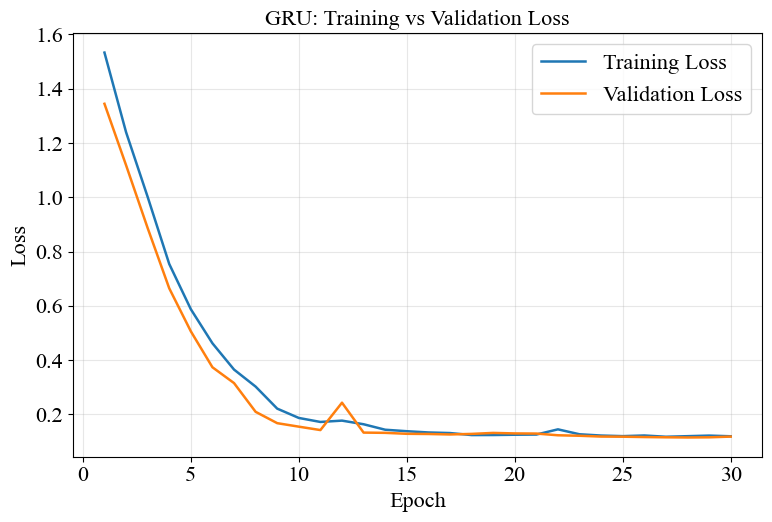

Saved (EPS, 37.9 KB): /content/plots/plot3_gru_accuracy_curve.eps


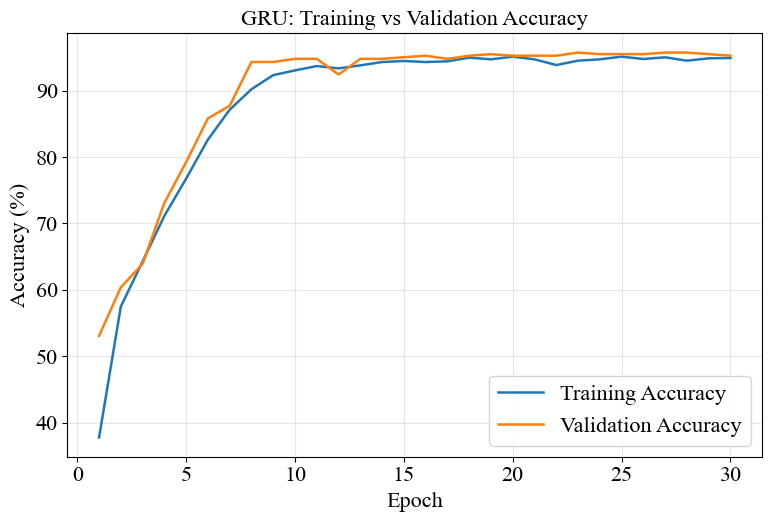

Saved (EPS, 36.6 KB): /content/plots/plot5_epochwise_val_loss_comparison.eps


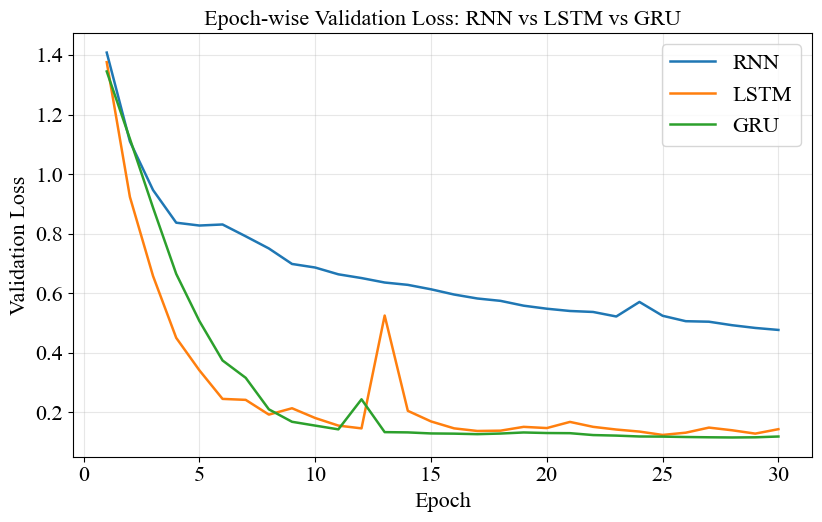

Saved (EPS, 40.8 KB): /content/plots/plot5_epochwise_val_accuracy_comparison.eps


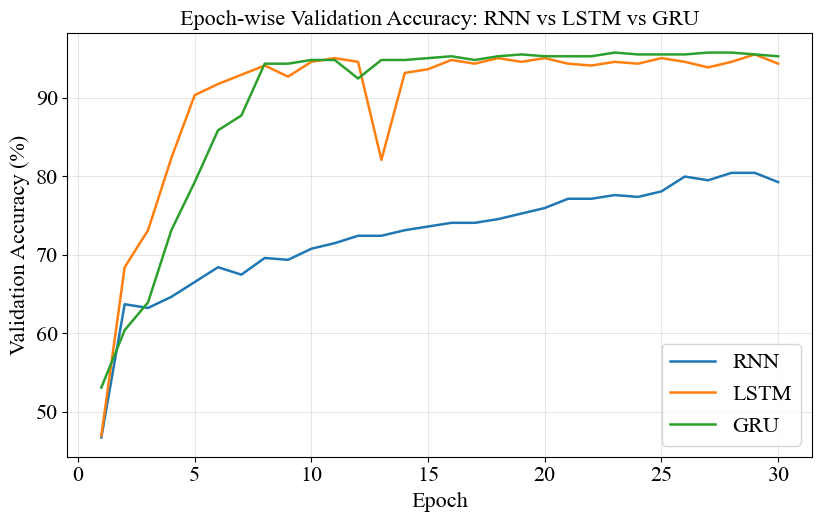

Saved (EPS, 36.8 KB): /content/plots/plot5_epochwise_train_loss_comparison.eps


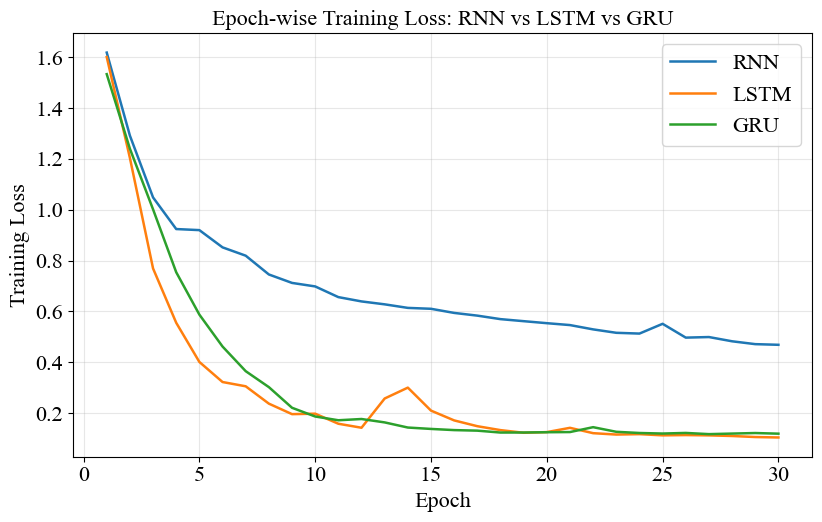

In [13]:
# =========================================================
# Block 7: Training Plots (Section 13) + Epoch-wise
# Cross-Model Comparison (replacing bar-chart Plot 5)
# =========================================================

histories = {
    "RNN": rnn_history,
    "LSTM": lstm_history,
    "GRU": gru_history,
}

# ---------------------------------------------------------
# Plot 2 & Plot 3: per-model Loss and Accuracy curves
# ---------------------------------------------------------
for model_name, history in histories.items():
    epochs_range = np.arange(1, len(history.history["loss"]) + 1)

    # Plot 2: Training vs Validation Loss
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.plot(epochs_range, history.history["loss"], label="Training Loss", linewidth=1.8)
    ax.plot(epochs_range, history.history["val_loss"], label="Validation Loss", linewidth=1.8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{model_name}: Training vs Validation Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    save_plot(fig, f"plot2_{model_name.lower()}_loss_curve")
    plt.show()

    # Plot 3: Training vs Validation Accuracy (%)
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.plot(epochs_range, np.array(history.history["accuracy"]) * 100,
            label="Training Accuracy", linewidth=1.8)
    ax.plot(epochs_range, np.array(history.history["val_accuracy"]) * 100,
            label="Validation Accuracy", linewidth=1.8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"{model_name}: Training vs Validation Accuracy")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    save_plot(fig, f"plot3_{model_name.lower()}_accuracy_curve")
    plt.show()

# ---------------------------------------------------------
# Epoch-wise Cross-Model Comparison
# (Plot 5 material: RNN vs LSTM vs GRU, overlaid per epoch)
# ---------------------------------------------------------
colors = {"RNN": "tab:blue", "LSTM": "tab:orange", "GRU": "tab:green"}

# Comparison: Validation Loss across models, per epoch
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for model_name, history in histories.items():
    epochs_range = np.arange(1, len(history.history["val_loss"]) + 1)
    ax.plot(epochs_range, history.history["val_loss"],
            label=model_name, linewidth=1.8, color=colors[model_name])
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title("Epoch-wise Validation Loss: RNN vs LSTM vs GRU")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_plot(fig, "plot5_epochwise_val_loss_comparison")
plt.show()

# Comparison: Validation Accuracy across models, per epoch
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for model_name, history in histories.items():
    epochs_range = np.arange(1, len(history.history["val_accuracy"]) + 1)
    ax.plot(epochs_range, np.array(history.history["val_accuracy"]) * 100,
            label=model_name, linewidth=1.8, color=colors[model_name])
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Epoch-wise Validation Accuracy: RNN vs LSTM vs GRU")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_plot(fig, "plot5_epochwise_val_accuracy_comparison")
plt.show()

# Comparison: Training Loss across models, per epoch (for convergence-speed comparison)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for model_name, history in histories.items():
    epochs_range = np.arange(1, len(history.history["loss"]) + 1)
    ax.plot(epochs_range, history.history["loss"],
            label=model_name, linewidth=1.8, color=colors[model_name])
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Epoch-wise Training Loss: RNN vs LSTM vs GRU")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_plot(fig, "plot5_epochwise_train_loss_comparison")
plt.show()

      Accuracy (%)  Macro Precision (%)  Macro Recall (%)  Macro F1 (%)  \
RNN         73.057               73.107            72.108        72.316   
LSTM        89.277               89.275            89.375        89.208   
GRU         90.431               90.431            90.550        90.414   

      Parameters  Training Time (s)  
RNN       1974.0             33.452  
LSTM      6006.0             25.673  
GRU       4758.0             24.448  
EPS too large (6257.2 KB) -> Saved (PDF, 38.4 KB): /content/plots/plot4_rnn_confusion_matrix.pdf


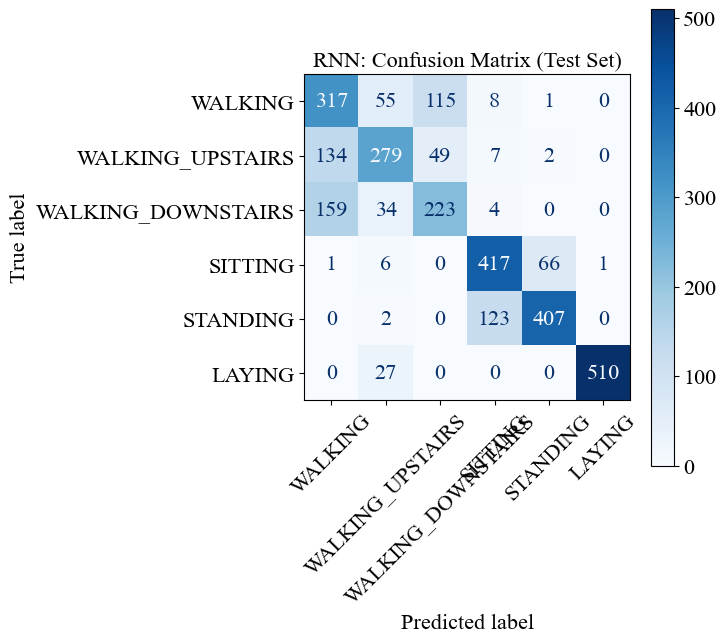

EPS too large (6257.2 KB) -> Saved (PDF, 27.6 KB): /content/plots/plot4_lstm_confusion_matrix.pdf


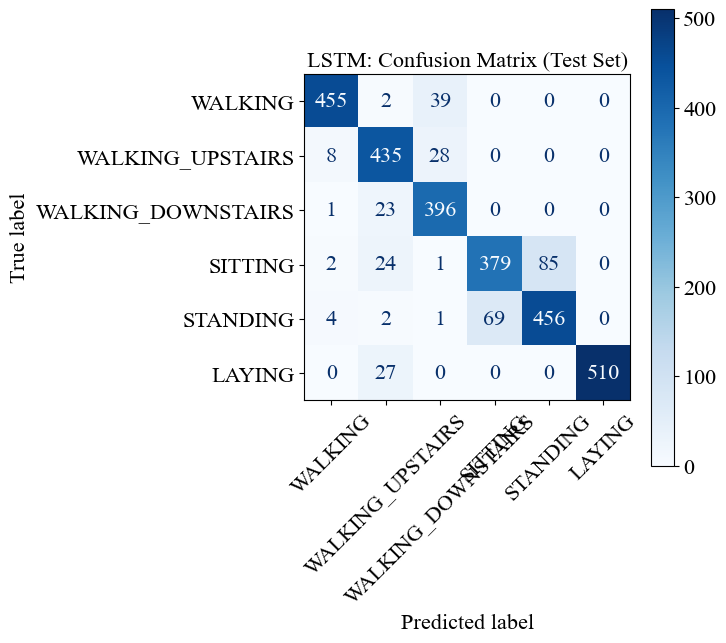

EPS too large (6257.1 KB) -> Saved (PDF, 27.6 KB): /content/plots/plot4_gru_confusion_matrix.pdf


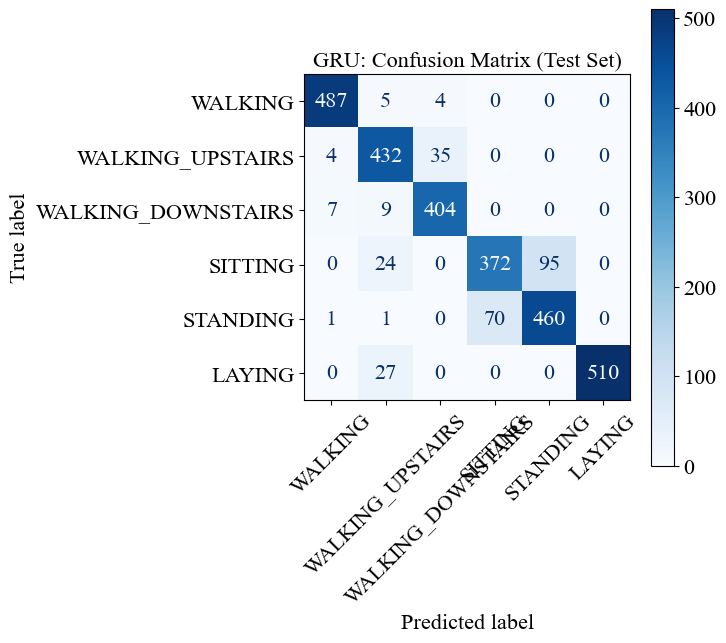


Classification reports saved to /content/classification_reports.txt


In [14]:
# =========================================================
# Block 8: Performance Evaluation (Section 14)
# Plot 4: Confusion Matrix per model
# =========================================================

models_dict = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
}

param_counts = {
    "RNN": rnn_num_params,
    "LSTM": lstm_num_params,
    "GRU": gru_num_params,
}

training_times = {
    "RNN": rnn_training_time,
    "LSTM": lstm_training_time,
    "GRU": gru_training_time,
}

evaluation_results = {}
predictions = {}

for model_name, model in models_dict.items():
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    predictions[model_name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    evaluation_results[model_name] = {
        "Accuracy (%)": acc * 100,
        "Macro Precision (%)": precision * 100,
        "Macro Recall (%)": recall * 100,
        "Macro F1 (%)": f1 * 100,
        "Parameters": param_counts[model_name],
        "Training Time (s)": training_times[model_name],
    }

# ---------------------------------------------------------
# Consolidated metrics table (Section 14)
# ---------------------------------------------------------
results_df = pd.DataFrame(evaluation_results).T
results_df = results_df[["Accuracy (%)", "Macro Precision (%)", "Macro Recall (%)",
                          "Macro F1 (%)", "Parameters", "Training Time (s)"]]
print(results_df.round(3))

results_df.to_csv("/content/metrics_rnn_lstm_gru.csv")

# ---------------------------------------------------------
# Plot 4: Confusion Matrix per model
# ---------------------------------------------------------
for model_name in models_dict.keys():
    cm = confusion_matrix(y_test, predictions[model_name])

    fig, ax = plt.subplots(figsize=(7.5, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ACTIVITY_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45, values_format="d")
    ax.set_title(f"{model_name}: Confusion Matrix (Test Set)")
    fig.tight_layout()
    save_plot(fig, f"plot4_{model_name.lower()}_confusion_matrix")
    plt.show()

# ---------------------------------------------------------
# Full classification report per model (for reference/debugging;
# not required as a plot, kept as raw text for the report appendix)
# ---------------------------------------------------------
classification_reports = {}
for model_name in models_dict.keys():
    report = classification_report(
        y_test, predictions[model_name],
        target_names=ACTIVITY_NAMES, zero_division=0
    )
    classification_reports[model_name] = report

with open("/content/classification_reports.txt", "w") as f:
    for model_name, report in classification_reports.items():
        f.write(f"=== {model_name} ===\n{report}\n\n")

print("\nClassification reports saved to /content/classification_reports.txt")


--- Training RNN | T=32 ---
RNN | T=32 | Test Macro F1: 69.89%

--- Training LSTM | T=32 ---
LSTM | T=32 | Test Macro F1: 86.72%

--- Training GRU | T=32 ---
GRU | T=32 | Test Macro F1: 83.99%

--- Training RNN | T=64 ---
RNN | T=64 | Test Macro F1: 67.76%

--- Training LSTM | T=64 ---
LSTM | T=64 | Test Macro F1: 89.94%

--- Training GRU | T=64 ---
GRU | T=64 | Test Macro F1: 90.40%

--- Training RNN | T=128 ---
RNN | T=128 | Test Macro F1: 66.53%

--- Training LSTM | T=128 ---
LSTM | T=128 | Test Macro F1: 88.76%

--- Training GRU | T=128 ---


GRU | T=128 | Test Macro F1: 88.51%

                     RNN    LSTM     GRU
Sequence Length                        
32               69.887  86.719  83.995
64               67.764  89.945  90.404
128              66.527  88.765  88.506
Saved (EPS, 38.8 KB): /content/plots/plot6_seqlen_vs_f1.eps


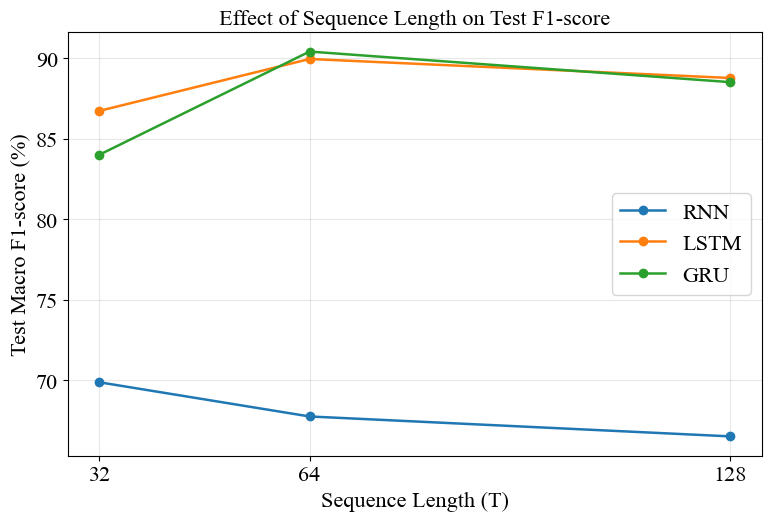

Saved (EPS, 39.6 KB): /content/plots/plot6b_rnn_epochwise_by_seqlen.eps


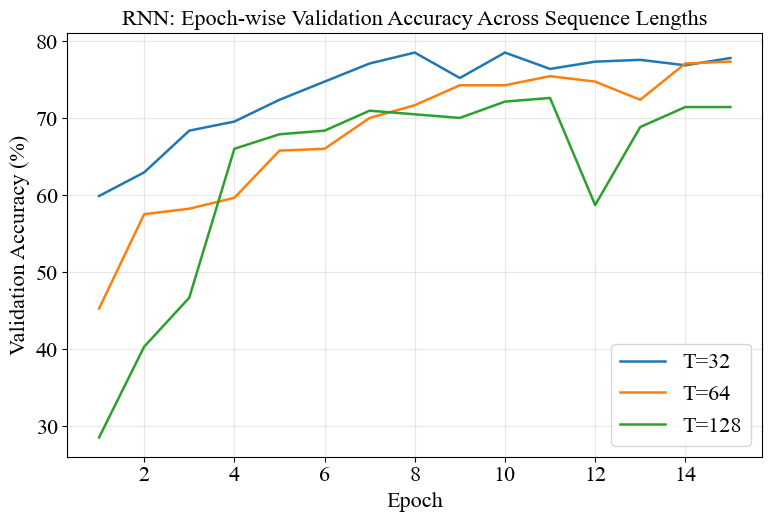

Saved (EPS, 39.1 KB): /content/plots/plot6b_lstm_epochwise_by_seqlen.eps


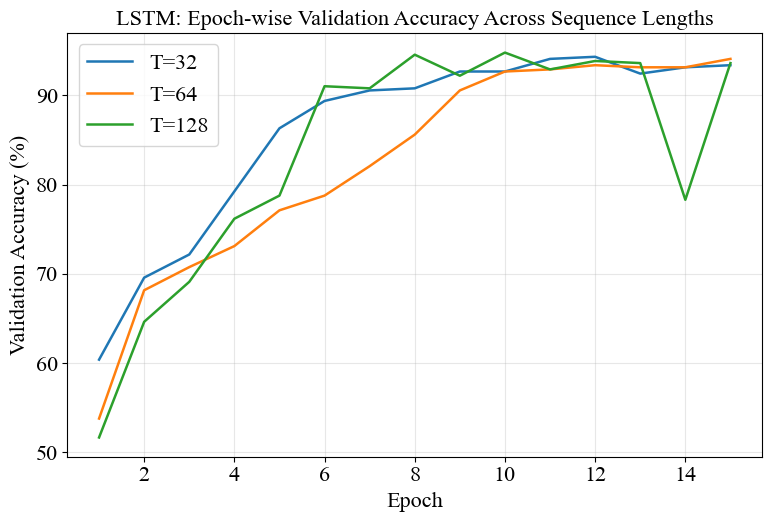

Saved (EPS, 40.9 KB): /content/plots/plot6b_gru_epochwise_by_seqlen.eps


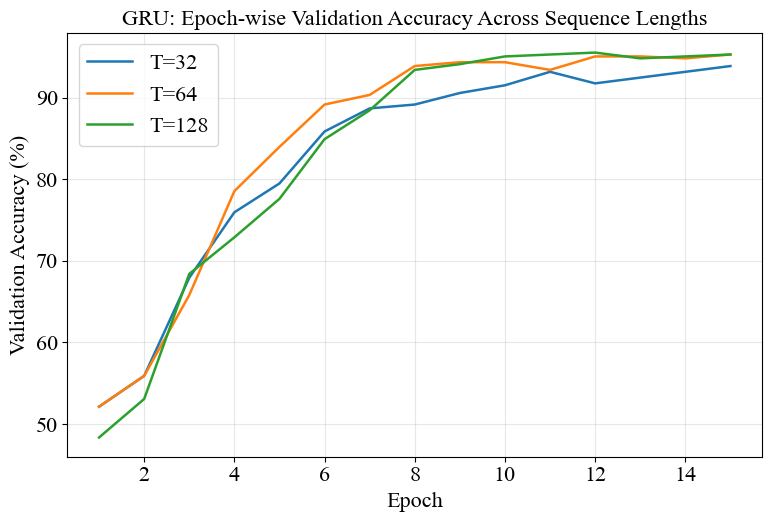

In [15]:
# =========================================================
# Block 9: Effect of Sequence Length (Section 17)
# Sweep T in {32, 64, 128} x {RNN, LSTM, GRU}
# Reduced epochs (15) per run for this section only.
# =========================================================

SEQ_LENGTHS = [32, 64, 128]
SEQLEN_EPOCHS = 15

def truncate_sequence(X, T):
    """
    Truncate the time axis to the first T steps, consistently
    across train/val/test. Shape: (N, 128, 9) -> (N, T, 9)
    """
    return X[:, :T, :]

def build_model_for_seqlen(arch, seq_len, n_features=NUM_FEATURES, n_classes=NUM_CLASSES):
    recurrent_layer = {
        "RNN": layers.SimpleRNN(32),
        "LSTM": layers.LSTM(32),
        "GRU": layers.GRU(32),
    }[arch]

    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        recurrent_layer,
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"{arch}_T{seq_len}")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# ---------------------------------------------------------
# Run the sweep, store test macro-F1 and histories
# ---------------------------------------------------------
seqlen_f1_results = {arch: {} for arch in ["RNN", "LSTM", "GRU"]}
seqlen_histories = {arch: {} for arch in ["RNN", "LSTM", "GRU"]}

for T in SEQ_LENGTHS:
    X_train_T = truncate_sequence(X_train_scaled, T)
    X_val_T   = truncate_sequence(X_val_scaled, T)
    X_test_T  = truncate_sequence(X_test_scaled, T)

    for arch in ["RNN", "LSTM", "GRU"]:
        print(f"\n--- Training {arch} | T={T} ---")
        model = build_model_for_seqlen(arch, T)

        history = model.fit(
            X_train_T, y_train,
            validation_data=(X_val_T, y_val),
            epochs=SEQLEN_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
        )

        y_pred = np.argmax(model.predict(X_test_T, verbose=0), axis=1)
        _, _, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="macro", zero_division=0
        )

        seqlen_f1_results[arch][T] = f1 * 100
        seqlen_histories[arch][T] = history

        print(f"{arch} | T={T} | Test Macro F1: {f1*100:.2f}%")

# ---------------------------------------------------------
# Consolidated Sequence Length vs. F1 table (Section 17)
# ---------------------------------------------------------
seqlen_df = pd.DataFrame(seqlen_f1_results)
seqlen_df.index.name = "Sequence Length"
print("\n", seqlen_df.round(3))
seqlen_df.to_csv("/content/seqlen_f1_results.csv")

# ---------------------------------------------------------
# Plot 6: Sequence Length vs. Test F1-score
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))
for arch in ["RNN", "LSTM", "GRU"]:
    f1_values = [seqlen_f1_results[arch][T] for T in SEQ_LENGTHS]
    ax.plot(SEQ_LENGTHS, f1_values, marker="o", linewidth=1.8,
            label=arch, color=colors[arch])
ax.set_xlabel("Sequence Length (T)")
ax.set_ylabel("Test Macro F1-score (%)")
ax.set_title("Effect of Sequence Length on Test F1-score")
ax.set_xticks(SEQ_LENGTHS)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_plot(fig, "plot6_seqlen_vs_f1")
plt.show()

# ---------------------------------------------------------
# Epoch-wise comparison across sequence lengths, per model
# (extending your epoch-wise comparison preference to this
# section as well: val accuracy per epoch, one plot per arch,
# lines = sequence length)
# ---------------------------------------------------------
for arch in ["RNN", "LSTM", "GRU"]:
    fig, ax = plt.subplots(figsize=(8, 5.5))
    for T in SEQ_LENGTHS:
        history = seqlen_histories[arch][T]
        epochs_range = np.arange(1, len(history.history["val_accuracy"]) + 1)
        ax.plot(epochs_range, np.array(history.history["val_accuracy"]) * 100,
                marker="", linewidth=1.8, label=f"T={T}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy (%)")
    ax.set_title(f"{arch}: Epoch-wise Validation Accuracy Across Sequence Lengths")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    save_plot(fig, f"plot6b_{arch.lower()}_epochwise_by_seqlen")
    plt.show()

In [17]:
# =========================================================
# Block 10a: Mini Installation — UCF101 Subset Download
# (5-class lightweight subset, avoids full 6.9GB rar archive)
# =========================================================

!wget -q https://git.io/JGc31 -O /content/ucf101_top5.tar.gz
!tar xf /content/ucf101_top5.tar.gz -C /content/

import glob

VIDEO_ROOT = "/content"
train_csv_path = os.path.join(VIDEO_ROOT, "train.csv")
test_csv_path = os.path.join(VIDEO_ROOT, "test.csv")

video_train_df = pd.read_csv(train_csv_path)
video_test_df = pd.read_csv(test_csv_path)

print("Train videos:", len(video_train_df))
print("Test videos :", len(video_test_df))
print("\nClass distribution (train):")
print(video_train_df["tag"].value_counts())

VIDEO_CLASSES = sorted(video_train_df["tag"].unique().tolist())
print("\nSelected action classes:", VIDEO_CLASSES)

Train videos: 594
Test videos : 224

Class distribution (train):
tag
Punch           121
PlayingCello    120
CricketShot     118
ShavingBeard    118
TennisSwing     117
Name: count, dtype: int64

Selected action classes: ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']


In [19]:
# =========================================================
# Block 10b: Frame Extraction + CNN Feature Extraction
# (Section 19-20)
# =========================================================

import cv2

IMG_SIZE = 224
FRAMES_PER_VIDEO = 10

def load_video_frames(video_path, max_frames=FRAMES_PER_VIDEO, resize=IMG_SIZE):
    """
    Uniformly sample `max_frames` frames from a video, resized
    to (resize, resize, 3). Returns array of shape (max_frames, resize, resize, 3).
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    total_frames = max(total_frames, max_frames)  # guard against corrupt metadata

    frame_indices = np.linspace(0, total_frames - 1, max_frames).astype(int)
    frames = []
    frame_idx = 0
    next_target = 0

    while cap.isOpened() and next_target < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx == frame_indices[next_target]:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (resize, resize))
            frames.append(frame)
            next_target += 1
        frame_idx += 1
    cap.release()

    # Pad with last frame if video was shorter than expected
    while len(frames) < max_frames:
        frames.append(frames[-1] if frames else np.zeros((resize, resize, 3), dtype=np.uint8))

    return np.array(frames, dtype=np.float32)

# ---------------------------------------------------------
# Frozen MobileNetV2 feature extractor (classification head removed)
# ---------------------------------------------------------
def build_feature_extractor():
    base = tf.keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base.trainable = False  # freeze - feature extraction only

    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))
    preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    outputs = base(preprocessed, training=False)
    return models.Model(inputs, outputs, name="MobileNetV2_FeatureExtractor")

feature_extractor = build_feature_extractor()
FEATURE_DIM = feature_extractor.output_shape[-1]
print(f"CNN feature dimension (D): {FEATURE_DIM}")

# ---------------------------------------------------------
# Extract (10, D) feature sequences for every video
# ---------------------------------------------------------
def extract_features_for_split(df, video_dir):
    all_features = []
    all_labels = []
    for _, row in df.iterrows():
        video_path = os.path.join(video_dir, row["video_name"])
        frames = load_video_frames(video_path)               # (10, 224, 224, 3)
        feats = feature_extractor.predict(frames, verbose=0)  # (10, D)
        all_features.append(feats)
        all_labels.append(row["tag"])
    X = np.stack(all_features, axis=0)   # (B, 10, D)
    y = np.array(all_labels)
    return X, y

label_to_idx = {cls: i for i, cls in enumerate(VIDEO_CLASSES)}

X_video_train_raw, y_video_train_raw = extract_features_for_split(
    video_train_df, os.path.join(VIDEO_ROOT, "train")
)
X_video_test, y_video_test_raw = extract_features_for_split(
    video_test_df, os.path.join(VIDEO_ROOT, "test")
)

y_video_train_raw = np.array([label_to_idx[c] for c in y_video_train_raw])
y_video_test = np.array([label_to_idx[c] for c in y_video_test_raw])

print("\nRequired observation (Section 20):")
print(f"  CNN feature dimension D: {FEATURE_DIM}")
print(f"  Feature tensor supplied to recurrent network: {X_video_train_raw.shape}")

# ---------------------------------------------------------
# Train/Validation split (test set stays separate, from test.csv)
# ---------------------------------------------------------
X_video_train, X_video_val, y_video_train, y_video_val = train_test_split(
    X_video_train_raw, y_video_train_raw,
    test_size=0.15,
    stratify=y_video_train_raw,
    random_state=SEED,
)

print(f"\nVideo train shape: {X_video_train.shape}")
print(f"Video val shape  : {X_video_val.shape}")
print(f"Video test shape : {X_video_test.shape}")

CNN feature dimension (D): 1280

Required observation (Section 20):
  CNN feature dimension D: 1280
  Feature tensor supplied to recurrent network: (594, 10, 1280)

Video train shape: (504, 10, 1280)
Video val shape  : (90, 10, 1280)
Video test shape : (224, 10, 1280)


Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5933 - loss: 1.0702 - val_accuracy: 0.9333 - val_loss: 0.6592
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9742 - loss: 0.3665 - val_accuracy: 0.9889 - val_loss: 0.2004
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9960 - loss: 0.1027 - val_accuracy: 0.9889 - val_loss: 0.0668
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0342 - val_accuracy: 0.9889 - val_loss: 0.0408
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0167 - val_accuracy: 0.9889 - val_loss: 0.0485
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0096 - val_accuracy: 0.9889 - val_loss: 0.0459
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 0.9889 - val_loss: 0.0395
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.9889 - val_loss

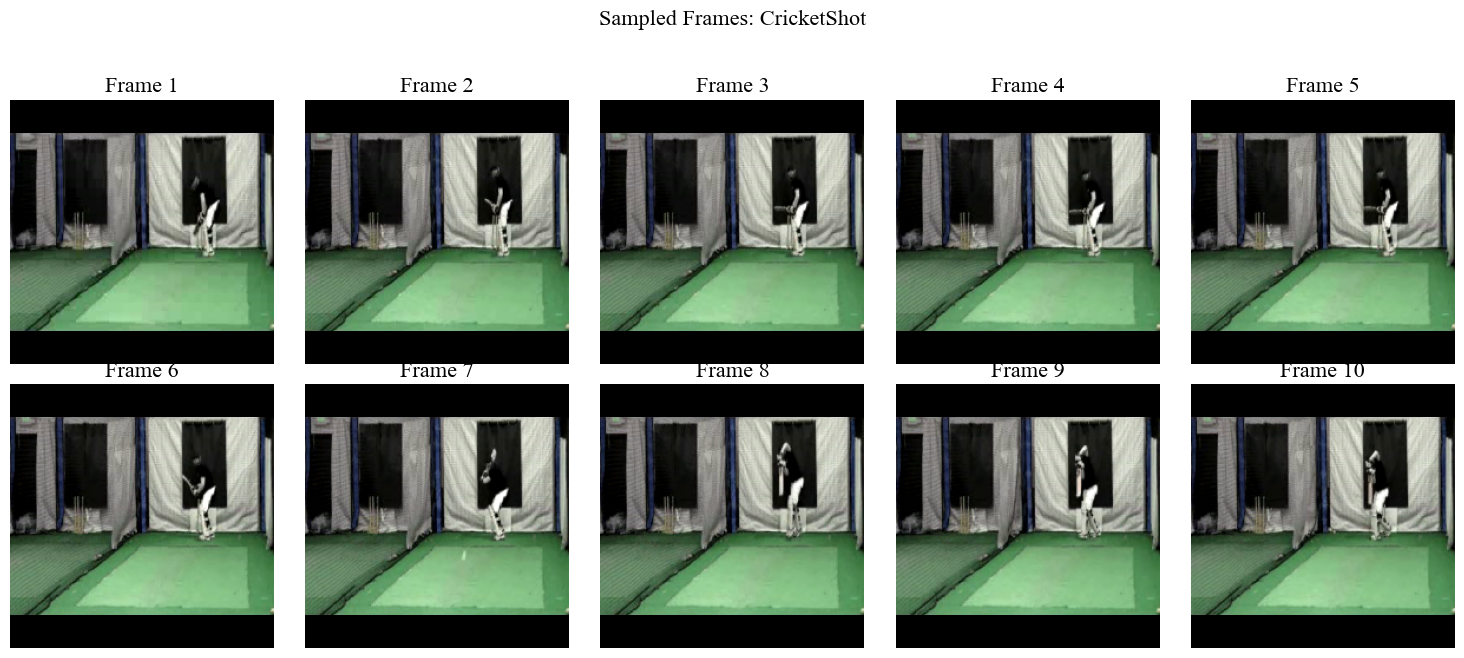

Saved (EPS, 50.5 KB): /content/plots/plot8_cnn_lstm_train_val_curves.eps


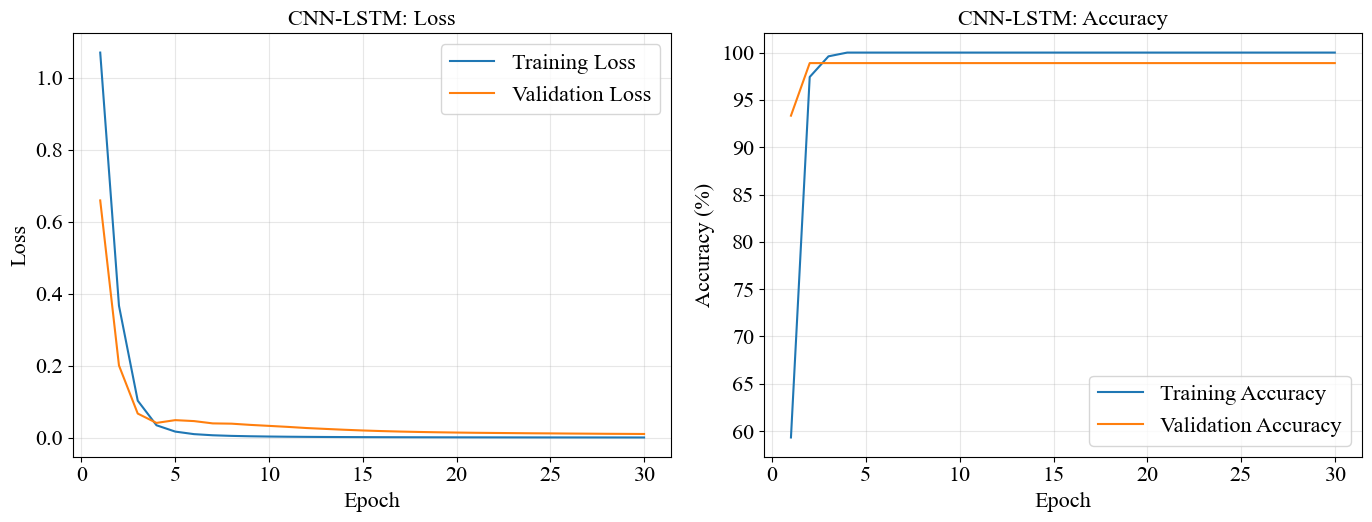

Saved (EPS, 50.7 KB): /content/plots/plot8_cnn_gru_train_val_curves.eps


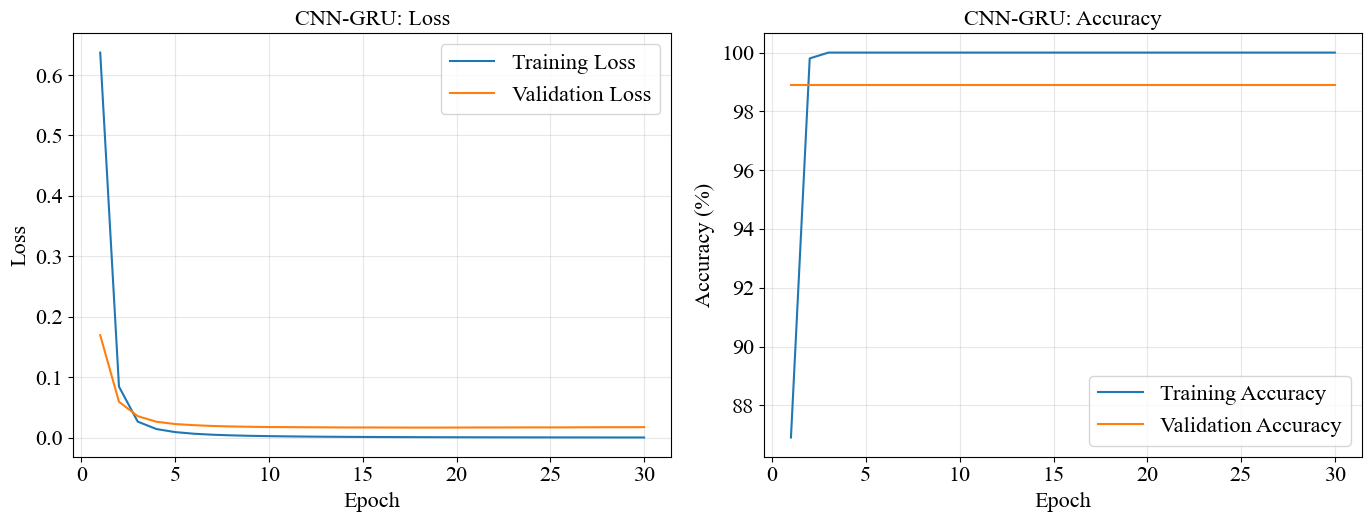

EPS too large (8874.4 KB) -> Saved (PDF, 27.7 KB): /content/plots/plot9_cnn_lstm_confusion_matrix.pdf


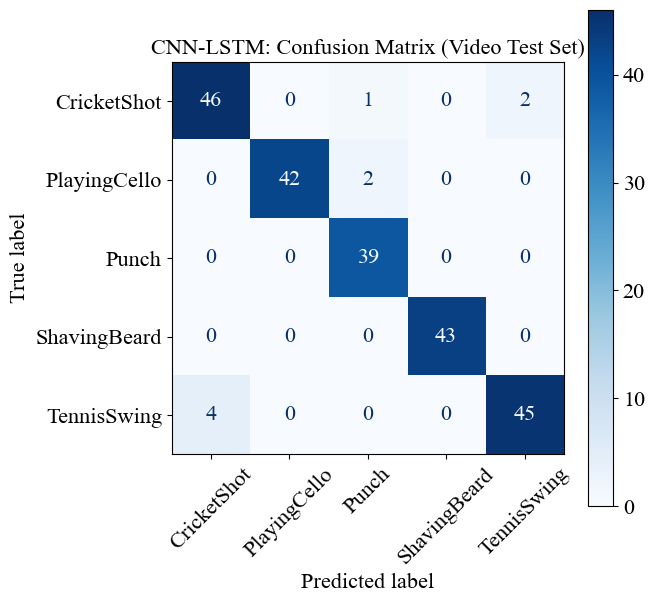

EPS too large (8877.1 KB) -> Saved (PDF, 28.2 KB): /content/plots/plot9_cnn_gru_confusion_matrix.pdf


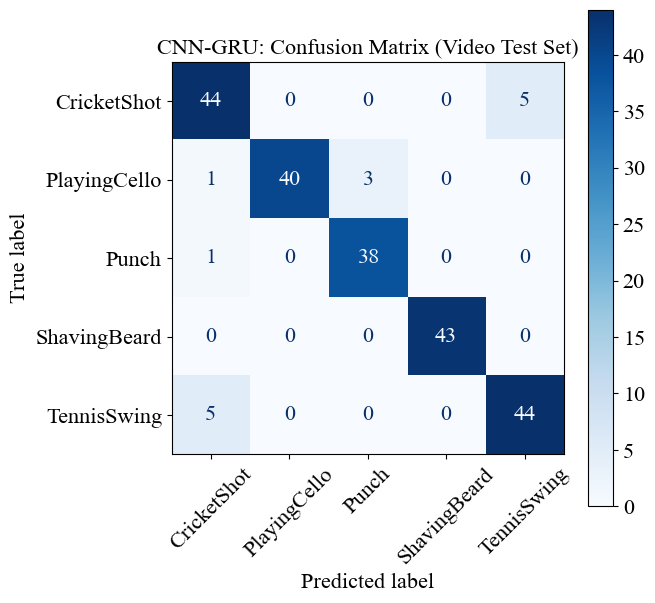

      Accuracy (%)  Macro Precision (%)  Macro Recall (%)  Macro F1 (%)  \
LSTM        95.982               96.120            96.234        96.130   
GRU         93.304               93.751            93.587        93.607   

      Parameters  
LSTM    168677.0  
GRU     126757.0  


In [20]:
# =========================================================
# Block 10c: CNN-LSTM / CNN-GRU Models (Section 21)
# Plot 7: Sample frames | Plot 8: Train/Val curves | Plot 9: Confusion Matrix
# =========================================================

def build_video_model(arch, seq_len=FRAMES_PER_VIDEO, feature_dim=FEATURE_DIM,
                       n_classes=len(VIDEO_CLASSES)):
    recurrent_layer = {
        "LSTM": layers.LSTM(32),
        "GRU": layers.GRU(32),
    }[arch]

    model = models.Sequential([
        layers.Input(shape=(seq_len, feature_dim)),
        recurrent_layer,
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"CNN_{arch}")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

VIDEO_EPOCHS = 30
video_models = {}
video_histories = {}
video_training_times = {}
video_param_counts = {}

for arch in ["LSTM", "GRU"]:
    model = build_video_model(arch)
    start_time = time.time()
    history = model.fit(
        X_video_train, y_video_train,
        validation_data=(X_video_val, y_video_val),
        epochs=VIDEO_EPOCHS,
        batch_size=8,
        verbose=1,
    )
    video_training_times[arch] = time.time() - start_time
    video_models[arch] = model
    video_histories[arch] = history
    video_param_counts[arch] = model.count_params()
    print(f"CNN-{arch} training time: {video_training_times[arch]:.2f}s | "
          f"Params: {video_param_counts[arch]}")

# ---------------------------------------------------------
# Plot 7: Video Sample Frames (one representative video)
# ---------------------------------------------------------
sample_row = video_train_df.iloc[0]
sample_video_path = os.path.join(VIDEO_ROOT, "train", sample_row["video_name"])
sample_frames = load_video_frames(sample_video_path)

fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_frames[i].astype(np.uint8))
    ax.set_title(f"Frame {i+1}")
    ax.axis("off")
fig.suptitle(f"Sampled Frames: {sample_row['tag']}", y=1.02)
fig.tight_layout()
save_plot(fig, "plot7_video_sample_frames")
plt.show()

# ---------------------------------------------------------
# Plot 8: Training/Validation Curves (Loss + Accuracy)
# ---------------------------------------------------------
for arch, history in video_histories.items():
    epochs_range = np.arange(1, len(history.history["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    axes[0].plot(epochs_range, history.history["loss"], label="Training Loss")
    axes[0].plot(epochs_range, history.history["val_loss"], label="Validation Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"CNN-{arch}: Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, np.array(history.history["accuracy"]) * 100, label="Training Accuracy")
    axes[1].plot(epochs_range, np.array(history.history["val_accuracy"]) * 100, label="Validation Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"CNN-{arch}: Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

    fig.tight_layout()
    save_plot(fig, f"plot8_cnn_{arch.lower()}_train_val_curves")
    plt.show()

# ---------------------------------------------------------
# Plot 9: Video Confusion Matrix (per architecture)
# ---------------------------------------------------------
video_predictions = {}
video_eval_results = {}

for arch, model in video_models.items():
    y_pred_probs = model.predict(X_video_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    video_predictions[arch] = y_pred

    acc = accuracy_score(y_video_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_video_test, y_pred, average="macro", zero_division=0
    )
    video_eval_results[arch] = {
        "Accuracy (%)": acc * 100, "Macro Precision (%)": precision * 100,
        "Macro Recall (%)": recall * 100, "Macro F1 (%)": f1 * 100,
        "Parameters": video_param_counts[arch],
    }

    cm = confusion_matrix(y_video_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=VIDEO_CLASSES)
    disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45, values_format="d")
    ax.set_title(f"CNN-{arch}: Confusion Matrix (Video Test Set)")
    fig.tight_layout()
    save_plot(fig, f"plot9_cnn_{arch.lower()}_confusion_matrix")
    plt.show()

video_results_df = pd.DataFrame(video_eval_results).T
print(video_results_df.round(3))
video_results_df.to_csv("/content/video_metrics_cnn_lstm_gru.csv")

In [21]:
# =========================================================
# Block 11a: Synthetic Reversal Dataset (Section 22)
# =========================================================

# Vocabulary: integers 0-9, plus special tokens
PAD_TOKEN, START_TOKEN, END_TOKEN = 10, 11, 12
VOCAB_SIZE = 13  # digits 0-9 + PAD + START + END

SEQ2SEQ_LEN = 4          # length of input integer sequence
NUM_SEQ2SEQ_SAMPLES = 20000

def generate_reversal_dataset(num_samples, seq_len, low=0, high=9, seed=SEED):
    rng = np.random.default_rng(seed)
    inputs = rng.integers(low, high + 1, size=(num_samples, seq_len))
    targets = inputs[:, ::-1].copy()
    return inputs, targets

def make_decoder_io(targets, start_token=START_TOKEN, end_token=END_TOKEN):
    """
    Build teacher-forcing decoder input (START + target) and
    decoder target (target + END), both padded to seq_len+1.
    """
    n, seq_len = targets.shape
    decoder_input = np.concatenate(
        [np.full((n, 1), start_token), targets], axis=1
    )
    decoder_target = np.concatenate(
        [targets, np.full((n, 1), end_token)], axis=1
    )
    return decoder_input, decoder_target

X_seq_in, y_seq_out = generate_reversal_dataset(NUM_SEQ2SEQ_SAMPLES, SEQ2SEQ_LEN)

# Train / val / test split (70/15/15)
X_s2s_train, X_s2s_temp, y_s2s_train, y_s2s_temp = train_test_split(
    X_seq_in, y_seq_out, test_size=0.30, random_state=SEED
)
X_s2s_val, X_s2s_test, y_s2s_val, y_s2s_test = train_test_split(
    X_s2s_temp, y_s2s_temp, test_size=0.50, random_state=SEED
)

dec_in_train, dec_tgt_train = make_decoder_io(y_s2s_train)
dec_in_val, dec_tgt_val = make_decoder_io(y_s2s_val)
dec_in_test, dec_tgt_test = make_decoder_io(y_s2s_test)

print("Seq2Seq train shapes:", X_s2s_train.shape, dec_in_train.shape, dec_tgt_train.shape)
print("Example  input :", X_s2s_train[0])
print("Example  target:", y_s2s_train[0])

Seq2Seq train shapes: (14000, 4) (14000, 5) (14000, 5)
Example  input : [3 0 3 4]
Example  target: [4 3 0 3]


In [22]:
# =========================================================
# Block 11b: Encoder-Decoder LSTM Model (Section 22)
# =========================================================

EMBED_DIM = 32
LSTM_UNITS = 64

def build_seq2seq_model(enc_len, dec_len, vocab_size=VOCAB_SIZE,
                         embed_dim=EMBED_DIM, units=LSTM_UNITS):
    # --- Encoder ---
    encoder_inputs = layers.Input(shape=(enc_len,), name="encoder_inputs")
    enc_emb = layers.Embedding(vocab_size, embed_dim, mask_zero=False)(encoder_inputs)
    _, state_h, state_c = layers.LSTM(units, return_state=True, name="encoder_lstm")(enc_emb)
    encoder_states = [state_h, state_c]

    # --- Decoder (teacher forcing during training) ---
    decoder_inputs = layers.Input(shape=(dec_len,), name="decoder_inputs")
    dec_emb_layer = layers.Embedding(vocab_size, embed_dim, mask_zero=False)
    dec_emb = dec_emb_layer(decoder_inputs)
    decoder_lstm = layers.LSTM(units, return_sequences=True, return_state=True, name="decoder_lstm")
    decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
    decoder_dense = layers.Dense(vocab_size, activation="softmax", name="decoder_output")
    decoder_outputs = decoder_dense(decoder_outputs)

    training_model = models.Model([encoder_inputs, decoder_inputs], decoder_outputs, name="Seq2Seq_Reversal")
    training_model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    # --- Inference sub-models (for greedy decoding) ---
    encoder_model = models.Model(encoder_inputs, encoder_states, name="Encoder_Inference")

    dec_state_input_h = layers.Input(shape=(units,))
    dec_state_input_c = layers.Input(shape=(units,))
    dec_states_inputs = [dec_state_input_h, dec_state_input_c]

    dec_single_input = layers.Input(shape=(1,))
    dec_single_emb = dec_emb_layer(dec_single_input)
    dec_single_out, dec_h, dec_c = decoder_lstm(dec_single_emb, initial_state=dec_states_inputs)
    dec_single_out = decoder_dense(dec_single_out)

    decoder_model = models.Model(
        [dec_single_input] + dec_states_inputs,
        [dec_single_out, dec_h, dec_c],
        name="Decoder_Inference",
    )

    return training_model, encoder_model, decoder_model


s2s_model, s2s_encoder_inf, s2s_decoder_inf = build_seq2seq_model(
    enc_len=SEQ2SEQ_LEN, dec_len=SEQ2SEQ_LEN + 1
)
s2s_model.summary()

s2s_start_time = time.time()
s2s_history = s2s_model.fit(
    [X_s2s_train, dec_in_train], dec_tgt_train,
    validation_data=([X_s2s_val, dec_in_val], dec_tgt_val),
    epochs=30,
    batch_size=64,
    verbose=1,
)
s2s_training_time = time.time() - s2s_start_time
print(f"\nSeq2Seq training time: {s2s_training_time:.2f} seconds")

Model: "Seq2Seq_Reversal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 32)     │        416 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 32)     │        416 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     24,832 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 64),   │     24,832 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 1, 13)     │        845 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,341 (200.55 KB)

 Trainable params: 51,341 (200.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4941 - loss: 1.4338 - val_accuracy: 0.8327 - val_loss: 0.5935
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9598 - loss: 0.2598 - val_accuracy: 0.9956 - val_loss: 0.1069
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9987 - loss: 0.0670 - val_accuracy: 0.9998 - val_loss: 0.0440
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9999 - loss: 0.0308 - val_accuracy: 0.9999 - val_loss: 0.0239
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 1.0000 - val_loss: 0.0150
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 0.0101
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 0.0072
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy:

Seq2Seq Test Loss (teacher-forced)    : 0.0001
Seq2Seq Test Accuracy (teacher-forced): 100.00%

[Subset of 100 test samples]
Token Accuracy   : 100.00%
Sequence Accuracy: 100.00%



 Input Sequence  True Output Predicted Output
  [4, 4, 0, 6] [6, 0, 4, 4]     [6, 0, 4, 4]
  [3, 1, 1, 3] [3, 1, 1, 3]     [3, 1, 1, 3]
  [5, 7, 4, 9] [9, 4, 7, 5]     [9, 4, 7, 5]
  [1, 5, 5, 4] [4, 5, 5, 1]     [4, 5, 5, 1]
  [2, 0, 7, 8] [8, 7, 0, 2]     [8, 7, 0, 2]
Saved (EPS, 37.2 KB): /content/plots/plot_seq2seq_loss_curve.eps


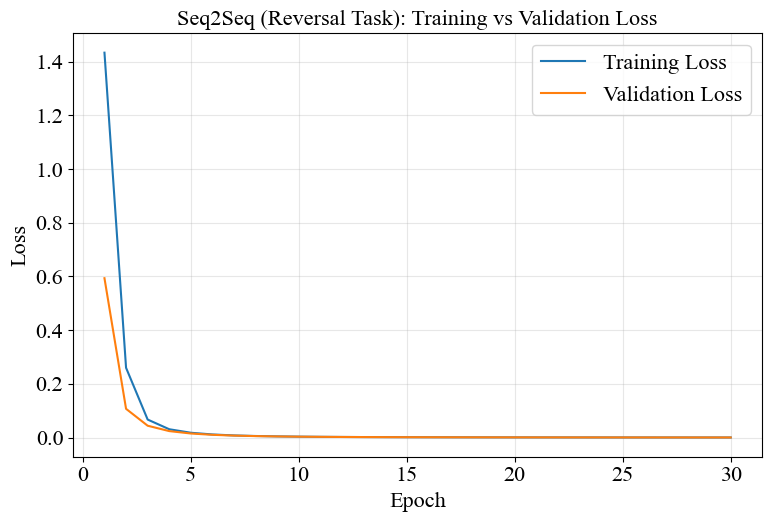

In [27]:
# =========================================================
# Block 11c (revised): Fast Evaluation + Capped Greedy Decoding
# Fixes Keras 3 static-shape tracing error and long runtime
# =========================================================

# ---------------------------------------------------------
# 1. Fast, parallel evaluation on the FULL test set using
#    teacher-forced inputs (overall loss/accuracy, not
#    autoregressive — but fast and shape-safe).
# ---------------------------------------------------------
s2s_test_loss, s2s_test_accuracy = s2s_model.evaluate(
    [X_s2s_test, dec_in_test], dec_tgt_test,
    batch_size=128, verbose=0,
)
print(f"Seq2Seq Test Loss (teacher-forced)    : {s2s_test_loss:.4f}")
print(f"Seq2Seq Test Accuracy (teacher-forced): {s2s_test_accuracy*100:.2f}%")

# ---------------------------------------------------------
# 2. Autoregressive greedy decoding fix: explicit NumPy
#    casting avoids Keras 3's static-shape tracing error
#    when slicing dynamic tensors inside a Python loop.
# ---------------------------------------------------------
def decode_sequence(input_row, encoder_model, decoder_model,
                     max_len=SEQ2SEQ_LEN, start_token=START_TOKEN, end_token=END_TOKEN):
    """
    Greedy decoding with explicit NumPy arrays at every step
    to avoid Keras 3 shape-tracing issues (as_list() error).
    """
    enc_input = np.array(input_row[np.newaxis, :], dtype=np.int32)
    states = encoder_model.predict(enc_input, verbose=0)

    target_token = np.array([[start_token]], dtype=np.int32)

    decoded_tokens = []
    for _ in range(max_len):
        output_tokens, h, c = decoder_model.predict(
            [target_token] + states, verbose=0
        )
        sampled_token = int(np.argmax(output_tokens[0, -1, :]))

        if sampled_token == end_token:
            break
        decoded_tokens.append(sampled_token)
        target_token = np.array([[sampled_token]], dtype=np.int32)
        states = [h, c]

    return decoded_tokens

# ---------------------------------------------------------
# 3. Evaluate sequence-level decoding on a capped subset
#    (autoregressive decoding is inherently sequential and
#    slow; a subset keeps runtime manageable).
# ---------------------------------------------------------
NUM_EVAL_SAMPLES = min(100, len(X_s2s_test))

correct_tokens = 0
total_tokens = 0
correct_sequences = 0
all_predictions = []

for i in range(NUM_EVAL_SAMPLES):
    input_row = np.array(X_s2s_test[i:i+1], dtype=np.int32)[0]
    pred = decode_sequence(input_row, s2s_encoder_inf, s2s_decoder_inf)
    true = y_s2s_test[i].tolist()
    all_predictions.append(pred)

    min_len = min(len(pred), len(true))
    correct_tokens += sum(p == t for p, t in zip(pred[:min_len], true[:min_len]))
    total_tokens += len(true)

    if pred == true:
        correct_sequences += 1

# ---------------------------------------------------------
# Global variables required by Block 12 (decimal values)
# ---------------------------------------------------------
token_accuracy = correct_tokens / total_tokens
sequence_accuracy = correct_sequences / NUM_EVAL_SAMPLES

print(f"\n[Subset of {NUM_EVAL_SAMPLES} test samples]")
print(f"Token Accuracy   : {token_accuracy*100:.2f}%")
print(f"Sequence Accuracy: {sequence_accuracy*100:.2f}%")

# ---------------------------------------------------------
# Display at least 5 test examples (Section 23 table)
# ---------------------------------------------------------
sample_results = []
for i in range(5):
    input_row = np.array(X_s2s_test[i:i+1], dtype=np.int32)[0]
    pred = decode_sequence(input_row, s2s_encoder_inf, s2s_decoder_inf)
    sample_results.append({
        "Input Sequence": X_s2s_test[i].tolist(),
        "True Output": y_s2s_test[i].tolist(),
        "Predicted Output": pred,
    })

sample_df = pd.DataFrame(sample_results)
print("\n", sample_df.to_string(index=False))
sample_df.to_csv("/content/seq2seq_sample_predictions.csv", index=False)

# ---------------------------------------------------------
# Training/Validation loss curve for seq2seq model
# ---------------------------------------------------------
epochs_range = np.arange(1, len(s2s_history.history["loss"]) + 1)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(epochs_range, s2s_history.history["loss"], label="Training Loss")
ax.plot(epochs_range, s2s_history.history["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Seq2Seq (Reversal Task): Training vs Validation Loss")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_plot(fig, "plot_seq2seq_loss_curve")
plt.show()

In [28]:
# =========================================================
# Block 12 (revised): Consolidated Results - Seq2Seq table
# Handles case where Additional Exercise 7 (Block 11d) was skipped
# =========================================================

seq2seq_rows = []

# Main reversal task (Block 11) — required, assumed run
seq2seq_rows.append({
    "Task": "Reversal (fixed length)",
    "Token Accuracy (%)": token_accuracy * 100,
    "Sequence Accuracy (%)": sequence_accuracy * 100,
    "Final Training Loss": s2s_history.history["loss"][-1],
    "Final Validation Loss": s2s_history.history["val_loss"][-1],
    "Parameters": s2s_model.count_params(),
    "Training Time (s)": s2s_training_time,
})

# Additional Exercise 7 — only included if Block 11d was run
if "ex7_model" in globals():
    seq2seq_rows.append({
        "Task": "Reverse + Append Max (Additional Ex. 7, variable length)",
        "Token Accuracy (%)": 100 * correct_tokens_ex7 / total_tokens_ex7,
        "Sequence Accuracy (%)": 100 * correct_sequences_ex7 / len(X_ex7_test),
        "Final Training Loss": ex7_history.history["loss"][-1],
        "Final Validation Loss": ex7_history.history["val_loss"][-1],
        "Parameters": ex7_model.count_params(),
        "Training Time (s)": np.nan,
    })
else:
    print("[Note] Additional Exercise 7 (Block 11d) not run — "
          "seq2seq table includes only the main reversal task.")

seq2seq_summary_df = pd.DataFrame(seq2seq_rows).set_index("Task")

print("\n=== Consolidated Results: Sequence-to-Sequence Task ===")
print(seq2seq_summary_df.round(4))
seq2seq_summary_df.to_csv("/content/consolidated_results_seq2seq.csv")

[Note] Additional Exercise 7 (Block 11d) not run — seq2seq table includes only the main reversal task.

=== Consolidated Results: Sequence-to-Sequence Task ===
                         Token Accuracy (%)  Sequence Accuracy (%)  \
Task                                                                 
Reversal (fixed length)               100.0                  100.0   

                         Final Training Loss  Final Validation Loss  \
Task                                                                  
Reversal (fixed length)               0.0001                 0.0001   

                         Parameters  Training Time (s)  
Task                                                    
Reversal (fixed length)       51341            79.3614  
